In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint,  solve_ivp
from scipy.optimize import curve_fit, fsolve
from scipy.signal import find_peaks
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

In [3]:
# Параметры моделей  (вариант 18)
epsilon_1 = 5 
gamma_1 = 3  
epsilon_2 = 3  
gamma_2 = 1  
alpha = 0.09

print(f"ε₁ (скорость роста жертв) = {epsilon_1}")
print(f"γ₁ (коэффициент хищничества) = {gamma_1}")
print(f"ε₂ (скорость смертности хищников) = {epsilon_2}")
print(f"γ₂ (коэффициент эффективности хищников) = {gamma_2}")
print(f"α (параметр возмущения) = {alpha}")

ε₁ (скорость роста жертв) = 5
γ₁ (коэффициент хищничества) = 3
ε₂ (скорость смертности хищников) = 3
γ₂ (коэффициент эффективности хищников) = 1
α (параметр возмущения) = 0.09


#### АНАЛИЗ МОДЕЛИ ЛОТКИ-ВОЛЬТЕРРЫ "ХИЩНИК-ЖЕРТВА"

In [4]:
# 1. Качественный анализ и точки равнорвесия

def lotka_volterra(t, y, eps1, gam1, eps2, gam2):
    """
    Классическая система Лотки-Вольтерры
    dN1/dt = (ε₁ - γ₁·N₂)·N₁
    dN2/dt = (-ε₂ + γ₂·N₁)·N₂
    """
    N1, N2 = y
    dN1dt = (eps1 - gam1 * N2) * N1
    dN2dt = (-eps2 + gam2 * N1) * N2
    return [dN1dt, dN2dt]

def find_equilibrium_points(eps1, gam1, eps2, gam2):
    """Нахождение точек равновесия"""
    # Тривиальное равновесие (вымирание обоих видов)
    eq_0 = (0, 0)
    
    # Нетривиальное равновесие (сосуществование)
    N1_star = eps2 / gam2
    N2_star = eps1 / gam1
    eq_star = (N1_star, N2_star)
    
    return eq_0, eq_star

def jacobian_matrix(N1, N2, eps1, gam1, eps2, gam2):
    """Вычисление матрицы Якоби в точке (N1, N2)"""
    df1_dN1 = eps1 - gam1 * N2
    df1_dN2 = -gam1 * N1
    df2_dN1 = gam2 * N2
    df2_dN2 = -eps2 + gam2 * N1
    
    J = np.array([[df1_dN1, df1_dN2],
                  [df2_dN1, df2_dN2]])
    return J

def analyze_stability(J):
    """Анализ устойчивости по собственным значениям"""
    eigenvalues = np.linalg.eigvals(J)
    trace = np.trace(J)
    determinant = np.linalg.det(J)
    
    return eigenvalues, trace, determinant

In [5]:
print("ТОЧКИ РАВНОВЕСИЯ И ЛИНЕАРИЗАЦИЯ")

eq_0, eq_star = find_equilibrium_points(epsilon_1, gamma_1, epsilon_2, gamma_2)

print(f"\nТочки равновесия:")
print(f"  1. Тривиальная: (N₁*, N₂*) = ({eq_0[0]}, {eq_0[1]})")
print(f"  2. Нетривиальная (сосуществование): (N₁*, N₂*) = ({eq_star[0]:.4f}, {eq_star[1]:.4f})")

N1_star, N2_star = eq_star
J_star = jacobian_matrix(N1_star, N2_star, epsilon_1, gamma_1, epsilon_2, gamma_2)
eigenvalues, trace, det = analyze_stability(J_star)

print(f"\nМатрица Якоби в нетривиальной точке равновесия:")
print(f"  J = \n{J_star}")
print(f"\n  След(J) = {trace:.4f}")
print(f"  Определитель(J) = {det:.4f}")
print(f"  Собственные значения: λ₁ = {eigenvalues[0]:.4f}, λ₂ = {eigenvalues[1]:.4f}")

print(f"\nСистема первого приближения в окрестности равновесия:")
print(f"  d(δN₁)/dt = -γ₁·N₁*·δN₂ = {-gamma_1 * N1_star:.4f}·δN₂")
print(f"  d(δN₂)/dt = γ₂·N₂*·δN₁ = {gamma_2 * N2_star:.4f}·δN₁")

ТОЧКИ РАВНОВЕСИЯ И ЛИНЕАРИЗАЦИЯ

Точки равновесия:
  1. Тривиальная: (N₁*, N₂*) = (0, 0)
  2. Нетривиальная (сосуществование): (N₁*, N₂*) = (3.0000, 1.6667)

Матрица Якоби в нетривиальной точке равновесия:
  J = 
[[ 0.         -9.        ]
 [ 1.66666667  0.        ]]

  След(J) = 0.0000
  Определитель(J) = 15.0000
  Собственные значения: λ₁ = 0.0000+3.8730j, λ₂ = 0.0000-3.8730j

Система первого приближения в окрестности равновесия:
  d(δN₁)/dt = -γ₁·N₁*·δN₂ = -9.0000·δN₂
  d(δN₂)/dt = γ₂·N₂*·δN₁ = 1.6667·δN₁


In [6]:
print("АНАЛИЗ УСТОЙЧИВОСТИ")

if trace == 0 and det > 0:
    print(f"\nТип точки: ЦЕНТР (нейтрально устойчива)")
    print(f" - Собственные значения чисто мнимые: ±{np.sqrt(det):.4f}i")
    print(f" - Траектории представляют собой замкнутые орбиты")
    print(f" - Система демонстрирует периодические колебания")
elif trace < 0 and det > 0:
    print(f"\nТип точки: УСТОЙЧИВЫЙ ФОКУС/УЗЕЛ")
elif trace > 0 and det > 0:
    print(f"\nТип точки: НЕУСТОЙЧИВЫЙ ФОКУС/УЗЕЛ")
else:
    print(f"\nТип точки: СЕДЛО (неустойчива)")
omega = np.sqrt(det)
T = 2 * np.pi / omega
print(f"\nЦиклическая частота: ω = {omega:.4f}")
print(f"Период малых колебаний: T = {T:.4f}")

АНАЛИЗ УСТОЙЧИВОСТИ

Тип точки: ЦЕНТР (нейтрально устойчива)
 - Собственные значения чисто мнимые: ±3.8730i
 - Траектории представляют собой замкнутые орбиты
 - Система демонстрирует периодические колебания

Циклическая частота: ω = 3.8730
Период малых колебаний: T = 1.6223



Решение для трёх начальных условий:
 НУ 1: N₁(0) = 2.5, N₂(0) = 1.5
 НУ 2: N₁(0) = 4.0, N₂(0) = 2.0
 НУ 3: N₁(0) = 1.0, N₂(0) = 0.5

ГРАФИКИ ДИНАМИКИ И ФАЗОВЫЙ ПОРТРЕТ


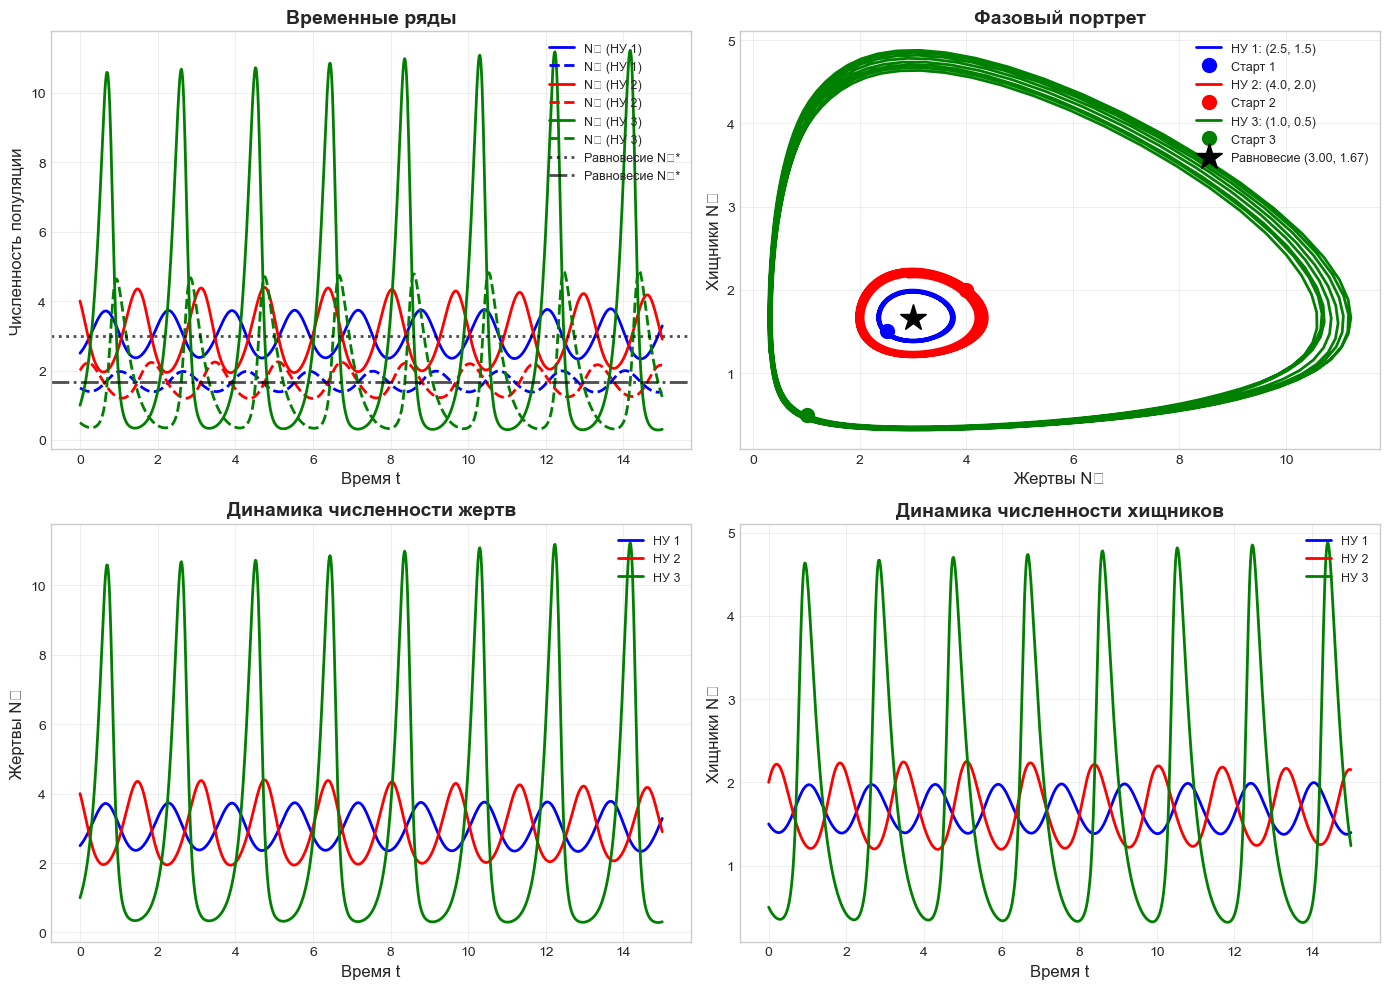

In [8]:
# Функция для построения графиков

def solve_and_plot(initial_conditions, t_span=(0, 15), title_suffix=""):
    """Решение системы и построение графиков"""
    t = np.linspace(t_span[0], t_span[1], 1000)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    colors = ['blue', 'red', 'green']
    
    ax1 = axes[0, 0]  # Временные ряды
    ax2 = axes[0, 1]  # Фазовый портрет
    ax3 = axes[1, 0]  # N1 от t
    ax4 = axes[1, 1]  # N2 от t
    
    solutions = []
    
    for i, (N1_0, N2_0) in enumerate(initial_conditions):
        sol = solve_ivp(lotka_volterra, t_span, [N1_0, N2_0], 
                       args=(epsilon_1, gamma_1, epsilon_2, gamma_2),
                       t_eval=t, dense_output=True)
        solutions.append(sol)
        
        N1 = sol.y[0]
        N2 = sol.y[1]
        
        # Временные ряды
        ax1.plot(t, N1, label=f'N₁ (НУ {i+1})', color=colors[i], linestyle='-', linewidth=2)
        ax1.plot(t, N2, label=f'N₂ (НУ {i+1})', color=colors[i], linestyle='--', linewidth=2)
        # Фазовый портрет
        ax2.plot(N1, N2, color=colors[i], label=f'НУ {i+1}: ({N1_0}, {N2_0})', linewidth=2)
        ax2.plot(N1[0], N2[0], 'o', color=colors[i], markersize=10, label=f'Старт {i+1}')
        # Индивидуальные графики
        ax3.plot(t, N1, color=colors[i], label=f'НУ {i+1}', linewidth=2)
        ax4.plot(t, N2, color=colors[i], label=f'НУ {i+1}', linewidth=2)
    
    # Отметка точки равновесия
    ax1.axhline(y=N1_star, color='black', linestyle=':', alpha=0.7, linewidth=2, label='Равновесие N₁*')
    ax1.axhline(y=N2_star, color='black', linestyle='-.', alpha=0.7, linewidth=2, label='Равновесие N₂*')
    ax2.plot(N1_star, N2_star, 'k*', markersize=20, label=f'Равновесие ({N1_star:.2f}, {N2_star:.2f})')
    
    ax1.set_xlabel('Время t', fontsize=12)
    ax1.set_ylabel('Численность популяции', fontsize=12)
    ax1.set_title(f'Временные ряды{title_suffix}', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper right', fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    ax2.set_xlabel('Жертвы N₁', fontsize=12)
    ax2.set_ylabel('Хищники N₂', fontsize=12)
    ax2.set_title(f'Фазовый портрет{title_suffix}', fontsize=14, fontweight='bold')
    ax2.legend(loc='best', fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    ax3.set_xlabel('Время t', fontsize=12)
    ax3.set_ylabel('Жертвы N₁', fontsize=12)
    ax3.set_title('Динамика численности жертв', fontsize=14, fontweight='bold')
    ax3.legend(loc='upper right', fontsize=9)
    ax3.grid(True, alpha=0.3)
    
    ax4.set_xlabel('Время t', fontsize=12)
    ax4.set_ylabel('Хищники N₂', fontsize=12)
    ax4.set_title('Динамика численности хищников', fontsize=14, fontweight='bold')
    ax4.legend(loc='upper right', fontsize=9)
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()  # Отображение графиков в ноутбуке
    
    return solutions

# Три различных начальных условия
initial_conditions = [
    (2.5, 1.5),   # Близко к равновесию
    (4.0, 2.0),   # Далеко от равновесия
    (1.0, 0.5)    # Другая точка
]

print(f"\nРешение для трёх начальных условий:")
for i, ic in enumerate(initial_conditions):
    print(f" НУ {i+1}: N₁(0) = {ic[0]}, N₂(0) = {ic[1]}")

print("\n" + "="*70)
print("ГРАФИКИ ДИНАМИКИ И ФАЗОВЫЙ ПОРТРЕТ")
print("="*70)

solutions = solve_and_plot(initial_conditions, t_span=(0, 15))

In [9]:
print("ХАРАКТЕРИСТИКИ КОЛЕБАТЕЛЬНОГО ПРОЦЕССА")

sol = solutions[0]
t = sol.t
N1 = sol.y[0]
N2 = sol.y[1]

peaks_N1, _ = find_peaks(N1, height=N1_star)
peaks_N2, _ = find_peaks(N2, height=N2_star)

if len(peaks_N1) > 1:
    periods_N1 = np.diff(t[peaks_N1])
    avg_period_N1 = np.mean(periods_N1)
    print(f"\nОценённый период по пикам N₁: T ≈ {avg_period_N1:.4f}")
    
if len(peaks_N2) > 1:
    periods_N2 = np.diff(t[peaks_N2])
    avg_period_N2 = np.mean(periods_N2)
    print(f"Оценённый период по пикам N₂: T ≈ {avg_period_N2:.4f}")

print(f"\nТеоретический период (малые колебания): T = {T:.4f}")
print(f"\nХарактеристики колебаний:")
print(f" • Колебания ПЕРИОДИЧЕСКИЕ и НЕЙТРАЛЬНО УСТОЙЧИВЫЕ")
print(f" • Амплитуда зависит от начальных условий")
print(f" • Фазовый сдвиг: хищники отстают от жертв на ~π/2")
print(f" • Период при малых отклонениях: T = {T:.4f} единиц времени")

ХАРАКТЕРИСТИКИ КОЛЕБАТЕЛЬНОГО ПРОЦЕССА

Оценённый период по пикам N₁: T ≈ 1.6254
Оценённый период по пикам N₂: T ≈ 1.6254

Теоретический период (малые колебания): T = 1.6223

Характеристики колебаний:
 • Колебания ПЕРИОДИЧЕСКИЕ и НЕЙТРАЛЬНО УСТОЙЧИВЫЕ
 • Амплитуда зависит от начальных условий
 • Фазовый сдвиг: хищники отстают от жертв на ~π/2
 • Период при малых отклонениях: T = 1.6223 единиц времени


In [10]:
# ВОПРОСЫ

print("\n1. КРИТЕРИЙ УСТОЙЧИВОСТИ ПО ПЕРВОМУ ПРИБЛИЖЕНИЮ:")
print("   Для системы dx/dt = f(x) с точкой равновесия x*:")
print("   • Линеаризуем: d(δx)/dt = J·δx, где J — матрица Якоби в точке x*")
print("   • Если ВСЕ собственные значения J имеют отрицательные вещественные части")
print("     → точка x* АСИМПТОТИЧЕСКИ УСТОЙЧИВА")
print("   • Если ХОТЯ БЫ ОДНО собственное значение имеет положительную вещественную часть")
print("     → точка x* НЕУСТОЙЧИВА")
print("   • Если собственные значения имеют нулевые вещественные части")
print("     → требуется нелинейный анализ (критический случай)")

print("\n2. ИССЛЕДОВАНИЕ УСТОЙЧИВОСТИ «ХИЩНИК-ЖЕРТВА» ПО ПЕРВОМУ ПРИБЛИЖЕНИЮ:")
print(f"   • Собственные значения: λ = ±{np.sqrt(det):.4f}i (чисто мнимые)")
print("   • След = 0, Определитель > 0 → ЦЕНТР")
print("   • Первое приближение показывает НЕЙТРАЛЬНУЮ УСТОЙЧИВОСТЬ")
print("   • Это КРИТИЧЕСКИЙ СЛУЧАЙ: линейный анализ НЕОДНОЗНАЧЕН")
print("   • Необходимо использовать функции Ляпунова или другие нелинейные методы")

print("\n3. ИДЕНТИФИКАЦИЯ ПАРАМЕТРОВ МОДЕЛИ ПО ЭМПИРИЧЕСКИМ ДАННЫМ:")
print("   Метод 1: Линейная регрессия на логарифмических производных")
print("   Из системы:")
print("     (1/N₁)·dN₁/dt = ε₁ - γ₁·N₂")
print("     (1/N₂)·dN₂/dt = -ε₂ + γ₂·N₁")
print("   Шаги:")
print("   a) Вычислить численные производные dN₁/dt, dN₂/dt")
print("   b) График (1/N₁)·dN₁/dt от N₂ → наклон = -γ₁, пересечение = ε₁")
print("   c) График (1/N₂)·dN₂/dt от N₁ → наклон = γ₂, пересечение = -ε₂")
print("   d) Метод наименьших квадратов для оценки параметров")

print("\n   Метод 2: Нелинейный метод наименьших квадратов")
print("   Минимизировать: Σ[(N₁_model - N₁_data)² + (N₂_model - N₂_data)²]")

print("\n4. ДОКАЗАТЕЛЬСТВО: УСРЕДНЁННЫЕ ЧИСЛЕННОСТИ = РАВНОВЕСНЫМ:")
print("   Шаг 1: Логарифмические производные")
print("     (1/N₁)·dN₁/dt = ε₁ - γ₁·N₂")
print("     (1/N₂)·dN₂/dt = -ε₂ + γ₂·N₁")
print()
print("   Шаг 2: Интегрирование по периоду T")
print("     ∫₀ d(ln N₁)/dt dt = 0  (периодичность)")
print("     ∫₀ d(ln N₂)/dt dt = 0  (периодичность)")
print()
print("   Шаг 3: Получаем")
print("     0 = ε₁·T - γ₁·∫₀ᵀ N₂ dt  →  ⟨N₂⟩ = ε₁/γ₁ = N₂*")
print("     0 = -ε₂·T + γ₂·∫₀ᵀ N₁ dt  →  ⟨N₁⟩ = ε₂/γ₂ = N₁*")
print()
print("   ВЫВОД: Усреднённые численности НЕ ЗАВИСЯТ от начальных условий!")
print(f"     ⟨N₁⟩ = {N1_star:.4f} = N₁*")
print(f"     ⟨N₂⟩ = {N2_star:.4f} = N₂*")


print("ЧИСЛЕННАЯ ПРОВЕРКА УСРЕДНЁННЫХ ЗНАЧЕНИЙ")
for i, sol in enumerate(solutions):
    t = sol.t
    N1 = sol.y[0]
    N2 = sol.y[1]
    
    t_avg = t[t > t[-1]/2]
    N1_avg = np.trapz(N1[t > t[-1]/2], t_avg) / len(t_avg)
    N2_avg = np.trapz(N2[t > t[-1]/2], t_avg) / len(t_avg)
    
    print(f"\nНУ {i+1}: ({initial_conditions[i][0]}, {initial_conditions[i][1]})")
    print(f"  ⟨N₁⟩ ≈ {N1_avg:.4f}  (vs N₁* = {N1_star:.4f})")
    print(f"  ⟨N₂⟩ ≈ {N2_avg:.4f}  (vs N₂* = {N2_star:.4f})")
    print(f"  Погрешность: ΔN₁ = {abs(N1_avg - N1_star)/N1_star*100:.2f}%, "
          f"ΔN₂ = {abs(N2_avg - N2_star)/N2_star*100:.2f}%")


1. КРИТЕРИЙ УСТОЙЧИВОСТИ ПО ПЕРВОМУ ПРИБЛИЖЕНИЮ:
   Для системы dx/dt = f(x) с точкой равновесия x*:
   • Линеаризуем: d(δx)/dt = J·δx, где J — матрица Якоби в точке x*
   • Если ВСЕ собственные значения J имеют отрицательные вещественные части
     → точка x* АСИМПТОТИЧЕСКИ УСТОЙЧИВА
   • Если ХОТЯ БЫ ОДНО собственное значение имеет положительную вещественную часть
     → точка x* НЕУСТОЙЧИВА
   • Если собственные значения имеют нулевые вещественные части
     → требуется нелинейный анализ (критический случай)

2. ИССЛЕДОВАНИЕ УСТОЙЧИВОСТИ «ХИЩНИК-ЖЕРТВА» ПО ПЕРВОМУ ПРИБЛИЖЕНИЮ:
   • Собственные значения: λ = ±3.8730i (чисто мнимые)
   • След = 0, Определитель > 0 → ЦЕНТР
   • Первое приближение показывает НЕЙТРАЛЬНУЮ УСТОЙЧИВОСТЬ
   • Это КРИТИЧЕСКИЙ СЛУЧАЙ: линейный анализ НЕОДНОЗНАЧЕН
   • Необходимо использовать функции Ляпунова или другие нелинейные методы

3. ИДЕНТИФИКАЦИЯ ПАРАМЕТРОВ МОДЕЛИ ПО ЭМПИРИЧЕСКИМ ДАННЫМ:
   Метод 1: Линейная регрессия на логарифмических производных
  

#### Модель Лотки-Вольтерры с логистической поправкой α, моделирующей взаимодействие популяций в условиях регулярного изъятия или пополнения популяций, когда оба вида представляют промысловую ценность

In [17]:
# 1. система уравнений с логистической поправкой (возмущением)

def lotka_volterra_logistic(t, y, eps1, gam1, eps2, gam2, alpha):
    """
    Модель Лотки-Вольтерры с логистической поправкой:
    dN1/dt = (ε₁ - γ₁·N₂)·N₁ - α·N₁²
    dN2/dt = (-ε₂ + γ₂·N₁)·N₂ - α·N₂²
    """
    N1, N2 = y
    dN1dt = (eps1 - gam1 * N2) * N1 - alpha * N1**2
    dN2dt = (-eps2 + gam2 * N1) * N2 - alpha * N2**2
    return [dN1dt, dN2dt]

# def find_equilibrium_points(eps1, gam1, eps2, gam2, alpha):
#     """
#     Нахождение ТОЛЬКО ВНУТРЕННЕЙ точки равновесия системы
#     (где обе популяции положительны)
#     """
#     equilibria = []
    
#     # Тривиальная точка (0, 0)
#     equilibria.append((0, 0))
    
#     # ВНУТРЕННЯЯ точка равновесия (N1 > 0, N2 > 0)
#     # Решаем линейную систему:
#     # ε₁ - γ₁·N₂ - α·N₁ = 0
#     # -ε₂ + γ₂·N₁ - α·N₂ = 0
    
#     if abs(alpha) < 1e-10:
#         # Классическая модель Лотки-Вольтерры (α = 0)
#         N1_star = eps2 / gam2
#         N2_star = eps1 / gam1
#         equilibria.append((N1_star, N2_star))
#     else:
#         # Система с логистической поправкой
#         # Переписываем в матричной форме:
#         # α·N₁ + γ₁·N₂ = ε₁
#         # γ₂·N₁ - α·N₂ = ε₂
        
#         # Определитель системы
#         det = -alpha**2 - gamma_1 * gamma_2
        
#         if abs(det) > 1e-10:
#             # Метод Крамера
#             N1_star = (eps1 * (-alpha) - gamma_1 * eps2) / det
#             N2_star = (alpha * eps1 - gamma_1 * eps2) / (-det)
            
#             # Проверяем, положительны ли значения
#             if N1_star > 0 and N2_star > 0:
#                 equilibria.append((N1_star, N2_star))
#                 print(f"✓ Найдена внутренняя точка: N₁* = {N1_star:.4f}, N₂* = {N2_star:.4f}")
#             else:
#                 print(f"⚠ Внутренняя точка имеет отрицательные координаты: "
#                       f"N₁* = {N1_star:.4f}, N₂* = {N2_star:.4f}")
#         else:
#             print("⚠ Система вырождена (det ≈ 0)")
    
#     return equilibria

def find_interior_equilibrium(eps1, gam1, eps2, gam2, alpha):
    """
    Нахождение ВНУТРЕННЕЙ точки равновесия (где обе популяции положительны)
    """
    if abs(alpha) < 1e-10:
        # Классическая модель Лотки-Вольтерры (α = 0)
        N1_star = eps2 / gam2
        N2_star = eps1 / gam1
        return (N1_star, N2_star)
    else:
        # Система с логистической поправкой
        # ε₁ - γ₁·N₂ - α·N₁ = 0
        # -ε₂ + γ₂·N₁ - α·N₂ = 0
        
        # Переписываем:
        # α·N₁ + γ₁·N₂ = ε₁
        # γ₂·N₁ - α·N₂ = ε₂
        
        # Определитель системы
        det = -alpha**2 - gam1 * gam2
        
        if abs(det) > 1e-10:
            # 🔧 ИСПРАВЛЕННЫЕ формулы метода Крамера:
            N1_star = (-alpha * eps1 - gam1 * eps2) / det
            N2_star = (gam2 * eps1 - alpha * eps2) / (-det)  # ← Здесь была ошибка!
            
            # Возвращаем только если обе координаты положительны
            if N1_star > 1e-10 and N2_star > 1e-10:
                print(f"✓ Найдена внутренняя точка: N₁* = {N1_star:.4f}, N₂* = {N2_star:.4f}")
                return (N1_star, N2_star)
            else:
                print(f"⚠ Внутренняя точка имеет отрицательные координаты: "
                      f"N₁* = {N1_star:.4f}, N₂* = {N2_star:.4f}")
                return None
        else:
            print("⚠ Система вырождена (det ≈ 0)")
            return None

def jacobian_matrix(N1, N2, eps1, gam1, eps2, gam2, alpha):
    """
    Матрица Якоби для системы с логистической поправкой
    """
    # f1 = (ε₁ - γ₁·N₂)·N₁ - α·N₁²
    # f2 = (-ε₂ + γ₂·N₁)·N₂ - α·N₂²
    
    df1_dN1 = eps1 - gam1 * N2 - 2 * alpha * N1
    df1_dN2 = -gam1 * N1
    df2_dN1 = gam2 * N2
    df2_dN2 = -eps2 + gam2 * N1 - 2 * alpha * N2
    
    J = np.array([[df1_dN1, df1_dN2],
                  [df2_dN1, df2_dN2]])
    return J

def analyze_equilibrium(J):
    """Анализ точки равновесия"""
    eigenvalues = np.linalg.eigvals(J)
    trace = np.trace(J)
    determinant = np.linalg.det(J)
    
    # Определяем тип точки
    if determinant < 0:
        eq_type = "СЕДЛО (неустойчиво)"
    elif trace < 0 and determinant > 0:
        if trace**2 - 4*determinant >= 0:
            eq_type = "УСТОЙЧИВЫЙ УЗЕЛ"
        else:
            eq_type = "УСТОЙЧИВЫЙ ФОКУС"
    elif trace > 0 and determinant > 0:
        if trace**2 - 4*determinant >= 0:
            eq_type = "НЕУСТОЙЧИВЫЙ УЗЕЛ"
        else:
            eq_type = "НЕУСТОЙЧИВЫЙ ФОКУС"
    elif trace == 0 and determinant > 0:
        eq_type = "ЦЕНТР (нейтрально)"
    else:
        eq_type = "ОСОБЫЙ СЛУЧАЙ"
    
    return {
        'eigenvalues': eigenvalues,
        'trace': trace,
        'determinant': determinant,
        'type': eq_type}

АНАЛИЗ (ПО ВАРИАНТУ + НЕСКОЛЬКО ДОПОЛНИТЕЛЬНЫХ) ПРИ РАЗЛИЧНЫХ ЗНАЧЕНИЯХ α ∈ [-1, 1]

   α     |   Точка равновесия   |            Тип            |   След   |   Опр.  
✓ Найдена внутренняя точка: N₁* = 3.1415, N₂* = 1.5724
  0.09   |     (3.14, 1.57)     |     УСТОЙЧИВЫЙ ФОКУС      |  -0.424  |  14.859 
✓ Найдена внутренняя точка: N₁* = 3.1415, N₂* = 1.5724
✓ Найдена внутренняя точка: N₁* = 3.2895, N₂* = 1.4474
  0.20   |     (3.29, 1.45)     |     УСТОЙЧИВЫЙ ФОКУС      |  -0.947  |  14.474 
✓ Найдена внутренняя точка: N₁* = 3.2895, N₂* = 1.4474
✓ Найдена внутренняя точка: N₁* = 3.5385, N₂* = 1.0769
  0.50   |     (3.54, 1.08)     |     УСТОЙЧИВЫЙ ФОКУС      |  -2.308  |  12.385 
✓ Найдена внутренняя точка: N₁* = 3.5385, N₂* = 1.0769


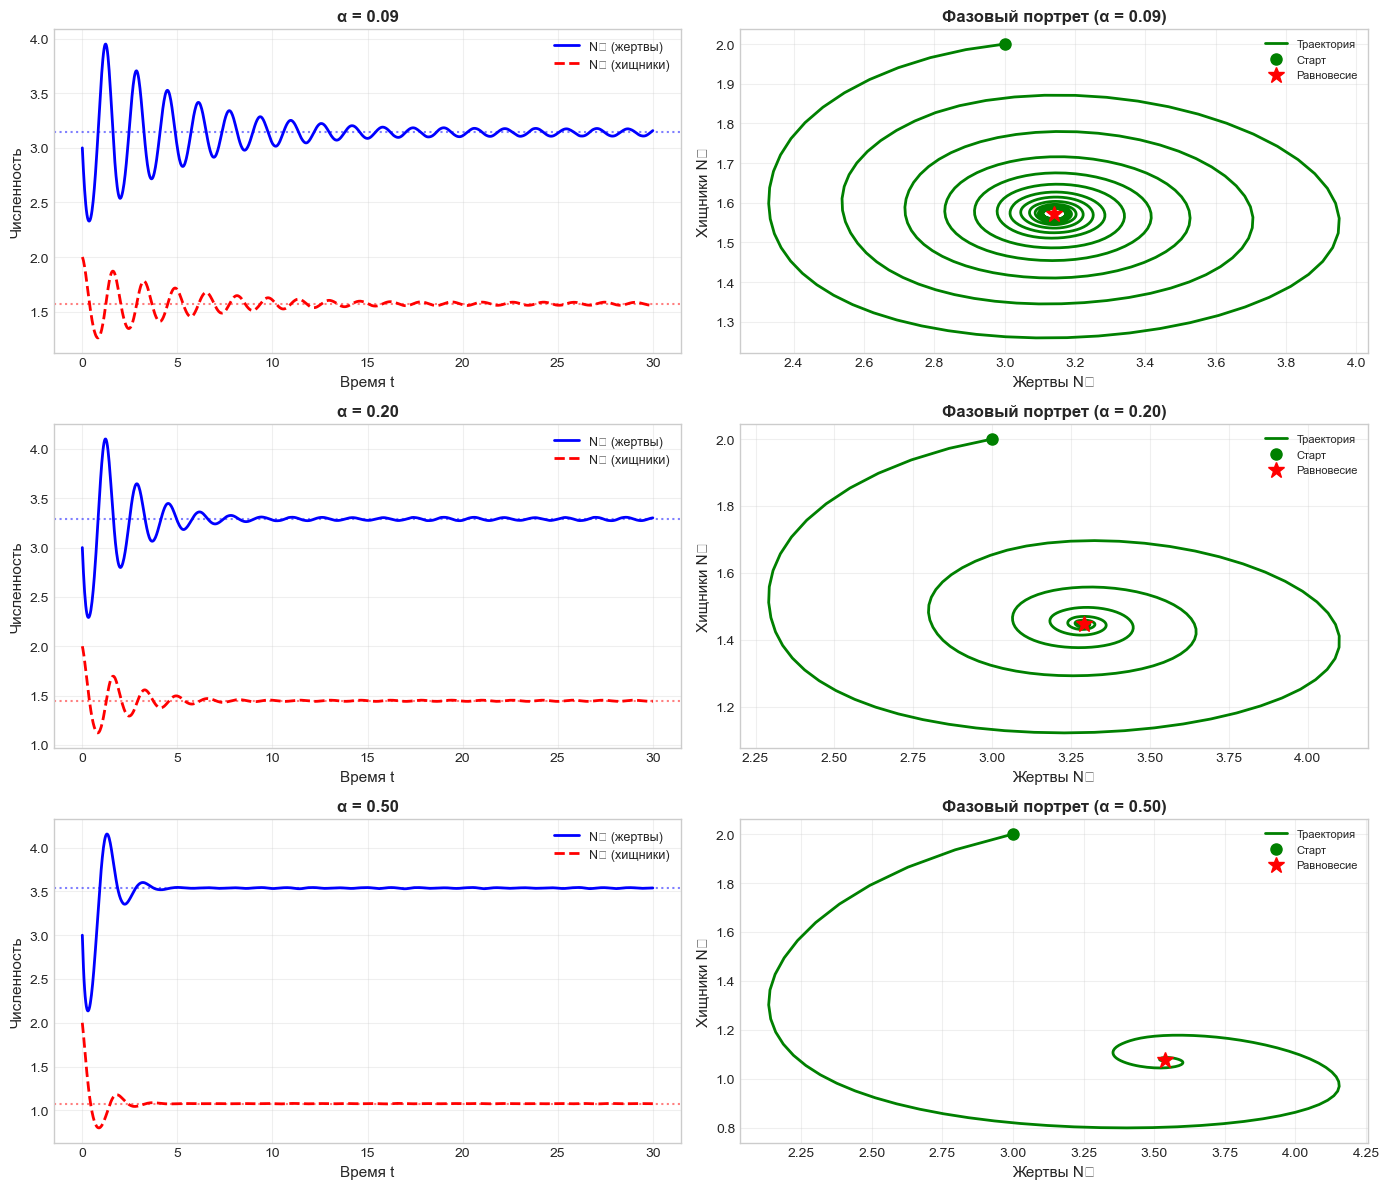

In [20]:
print("АНАЛИЗ (ПО ВАРИАНТУ + НЕСКОЛЬКО ДОПОЛНИТЕЛЬНЫХ) ПРИ РАЗЛИЧНЫХ ЗНАЧЕНИЯХ α ∈ [-1, 1]")

# Выбираем значения α для исследования
alpha_values = [0.09, 0.2, 0.5]
initial_condition = (3.0, 2.0)  # Начальное условие
t_span = (0, 30)

# def plot_for_alpha(alpha_val, ax_time=None, ax_phase=None):
#     """Построение графиков для конкретного α"""
    
#     # Находим точки равновесия
#     equilibria = find_equilibrium_points(epsilon_1, gamma_1, epsilon_2, gamma_2, alpha_val)
    
#     # Анализируем внутреннюю точку равновесия
#     if len(equilibria) > 1:
#         interior_eq = equilibria[-1]  # Последняя точка - внутренняя
#         J = jacobian_matrix(interior_eq[0], interior_eq[1], 
#                            epsilon_1, gamma_1, epsilon_2, gamma_2, alpha_val)
#         analysis = analyze_equilibrium(J)
#     else:
#         interior_eq = None
#         analysis = None
    
#     # Численное решение
#     t = np.linspace(t_span[0], t_span[1], 1000)
#     sol = solve_ivp(lotka_volterra_logistic, t_span, initial_condition,
#                    args=(epsilon_1, gamma_1, epsilon_2, gamma_2, alpha_val),
#                    t_eval=t, dense_output=True)
#     N1 = sol.y[0]
#     N2 = sol.y[1]
    
#     # Временные ряды
#     if ax_time:
#         ax_time.plot(t, N1, 'b-', linewidth=2, label=f'N₁ (жертвы)')
#         ax_time.plot(t, N2, 'r--', linewidth=2, label=f'N₂ (хищники)')
#         if interior_eq:
#             ax_time.axhline(y=interior_eq[0], color='blue', linestyle=':', alpha=0.5)
#             ax_time.axhline(y=interior_eq[1], color='red', linestyle=':', alpha=0.5)
#         ax_time.set_xlabel('Время t', fontsize=11)
#         ax_time.set_ylabel('Численность', fontsize=11)
#         ax_time.set_title(f'α = {alpha_val:.2f}', fontsize=12, fontweight='bold')
#         ax_time.legend(loc='best', fontsize=9)
#         ax_time.grid(True, alpha=0.3)
    
#     # Фазовый портрет
#     if ax_phase:
#         ax_phase.plot(N1, N2, 'g-', linewidth=2, label='Траектория')
#         ax_phase.plot(initial_condition[0], initial_condition[1], 'go', markersize=8, label='Старт')
        
#         # Отмечаем точки равновесия
#         for i, eq in enumerate(equilibria):
#             if eq[0] >= 0 and eq[1] >= 0 and eq[0] <= max(N1)*1.1 and eq[1] <= max(N2)*1.1:
#                 if i == 0:
#                     ax_phase.plot(eq[0], eq[1], 'k*', markersize=10, label='(0,0)')
#                 elif i == len(equilibria) - 1 and interior_eq:
#                     ax_phase.plot(eq[0], eq[1], 'r*', markersize=12, label=f'Равновесие')
#                 else:
#                     ax_phase.plot(eq[0], eq[1], 'm*', markersize=8)
#         ax_phase.set_xlabel('Жертвы N₁', fontsize=11)
#         ax_phase.set_ylabel('Хищники N₂', fontsize=11)
#         ax_phase.set_title(f'Фазовый портрет (α = {alpha_val:.2f})', fontsize=12, fontweight='bold')
#         ax_phase.legend(loc='best', fontsize=8)
#         ax_phase.grid(True, alpha=0.3)
    
#     return interior_eq, analysis

def plot_for_alpha(alpha_val, ax_time=None, ax_phase=None):
    """Построение графиков для конкретного α"""
    
    # ИСПРАВЛЕНИЕ: находим только внутреннюю точку
    interior_eq = find_interior_equilibrium(epsilon_1, gamma_1, epsilon_2, gamma_2, alpha_val)
    
    if interior_eq:
        J = jacobian_matrix(interior_eq[0], interior_eq[1], 
                           epsilon_1, gamma_1, epsilon_2, gamma_2, alpha_val)
        analysis = analyze_equilibrium(J)
    else:
        analysis = None
    
    # Численное решение
    t = np.linspace(t_span[0], t_span[1], 1000)
    sol = solve_ivp(lotka_volterra_logistic, t_span, initial_condition,
                   args=(epsilon_1, gamma_1, epsilon_2, gamma_2, alpha_val),
                   t_eval=t, dense_output=True)
    N1 = sol.y[0]
    N2 = sol.y[1]
    
    # Временные ряды
    if ax_time:
        ax_time.plot(t, N1, 'b-', linewidth=2, label=f'N₁ (жертвы)')
        ax_time.plot(t, N2, 'r--', linewidth=2, label=f'N₂ (хищники)')
        if interior_eq:
            ax_time.axhline(y=interior_eq[0], color='blue', linestyle=':', alpha=0.5)
            ax_time.axhline(y=interior_eq[1], color='red', linestyle=':', alpha=0.5)
        ax_time.set_xlabel('Время t', fontsize=11)
        ax_time.set_ylabel('Численность', fontsize=11)
        ax_time.set_title(f'α = {alpha_val:.2f}', fontsize=12, fontweight='bold')
        ax_time.legend(loc='best', fontsize=9)
        ax_time.grid(True, alpha=0.3)
    
    # Фазовый портрет
    if ax_phase:
        ax_phase.plot(N1, N2, 'g-', linewidth=2, label='Траектория')
        ax_phase.plot(initial_condition[0], initial_condition[1], 'go', markersize=8, label='Старт')
        
        # Отмечаем только внутреннюю точку равновесия
        if interior_eq:
            ax_phase.plot(interior_eq[0], interior_eq[1], 'r*', markersize=12, label=f'Равновесие')
        
        ax_phase.set_xlabel('Жертвы N₁', fontsize=11)
        ax_phase.set_ylabel('Хищники N₂', fontsize=11)
        ax_phase.set_title(f'Фазовый портрет (α = {alpha_val:.2f})', fontsize=12, fontweight='bold')
        ax_phase.legend(loc='best', fontsize=8)
        ax_phase.grid(True, alpha=0.3)
    
    return interior_eq, analysis

# Создаем фигуру с подграфиками
fig, axes = plt.subplots(len(alpha_values), 2, figsize=(14, 4*len(alpha_values)))

print(f"\n{'α':^8} | {'Точка равновесия':^20} | {'Тип':^25} | {'След':^8} | {'Опр.':^8}")

# for idx, alpha_val in enumerate(alpha_values):
#     interior_eq, analysis = plot_for_alpha(alpha_val, 
#                                             ax_time=axes[idx, 0] if len(alpha_values) > 1 else axes[0],
#                                             ax_phase=axes[idx, 1] if len(alpha_values) > 1 else axes[1])
    
#     if interior_eq and analysis:
#         print(f"{alpha_val:^8.2f} | ({interior_eq[0]:.2f}, {interior_eq[1]:.2f}) | "
#               f"{analysis['type']:^25} | {analysis['trace']:^8.3f} | {analysis['determinant']:^8.3f}")
#     else:
#         print(f"{alpha_val:^8.2f} | Нет внутренней точки")
# plt.tight_layout()
# plt.show()

for idx, alpha_val in enumerate(alpha_values):
    # используем новую функцию
    interior_eq = find_interior_equilibrium(epsilon_1, gamma_1, epsilon_2, gamma_2, alpha_val)
    
    if interior_eq:
        J = jacobian_matrix(interior_eq[0], interior_eq[1], 
                           epsilon_1, gamma_1, epsilon_2, gamma_2, alpha_val)
        analysis = analyze_equilibrium(J)
        
        point_str = f"({interior_eq[0]:.2f}, {interior_eq[1]:.2f})"
        print(f"{alpha_val:^8.2f} | {point_str:^20} | {analysis['type']:^25} | "
              f"{analysis['trace']:^8.3f} | {analysis['determinant']:^8.3f}")
    else:
        print(f"{alpha_val:^8.2f} | {'Нет внутренней точки':^20} | {'-':^25} | {'-':^8} | {'-':^8}")
    
    # Построение графиков (без изменений, но используем interior_eq)
    interior_eq, analysis = plot_for_alpha(alpha_val, 
                                            ax_time=axes[idx, 0],
                                            ax_phase=axes[idx, 1])
plt.tight_layout()
plt.show()

In [13]:
# print("ДЕТАЛЬНЫЙ АНАЛИЗ ПРИ α = 0.09")

# alpha_val = 0.09
# equilibria = find_equilibrium_points(epsilon_1, gamma_1, epsilon_2, gamma_2, alpha_val)

# print(f"\nТочки равновесия при α = {alpha_val}:")
# for i, eq in enumerate(equilibria):
#     if eq[0] >= 0 and eq[1] >= 0:
#         J = jacobian_matrix(eq[0], eq[1], epsilon_1, gamma_1, epsilon_2, gamma_2, alpha_val)
#         analysis = analyze_equilibrium(J)
#         print(f"\n  {i+1}. ({eq[0]:.4f}, {eq[1]:.4f})")
#         print(f" Тип: {analysis['type']}")
#         print(f" Собственные значения: λ₁ = {analysis['eigenvalues'][0]:.4f}, λ₂ = {analysis['eigenvalues'][1]:.4f}")
#         print(f" След: {analysis['trace']:.4f}, Определитель: {analysis['determinant']:.4f}")

# # Построение детальных графиков
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# t = np.linspace(0, 50, 1000)
# sol = solve_ivp(lotka_volterra_logistic, (0, 50), initial_condition,
#                args=(epsilon_1, gamma_1, epsilon_2, gamma_2, alpha_val),
#                t_eval=t, dense_output=True)

# # Временные ряды
# axes[0].plot(t, sol.y[0], 'b-', linewidth=2.5, label='N₁ (жертвы)')
# axes[0].plot(t, sol.y[1], 'r--', linewidth=2.5, label='N₂ (хищники)')

# # Отмечаем равновесие
# interior_eq = equilibria[-1]
# axes[0].axhline(y=interior_eq[0], color='blue', linestyle=':', linewidth=2, alpha=0.7, label=f'N₁* = {interior_eq[0]:.2f}')
# axes[0].axhline(y=interior_eq[1], color='red', linestyle=':', linewidth=2, alpha=0.7, label=f'N₂* = {interior_eq[1]:.2f}')

# axes[0].set_xlabel('Время t', fontsize=12)
# axes[0].set_ylabel('Численность популяции', fontsize=12)
# axes[0].set_title(f'Динамика популяций при α = {alpha_val}', fontsize=14, fontweight='bold')
# axes[0].legend(loc='best', fontsize=11)
# axes[0].grid(True, alpha=0.3)

# # Фазовый портрет
# axes[1].plot(sol.y[0], sol.y[1], 'g-', linewidth=2.5, label='Траектория')
# axes[1].plot(initial_condition[0], initial_condition[1], 'go', markersize=10, label='Начальная точка')
# axes[1].plot(interior_eq[0], interior_eq[1], 'r*', markersize=20, label=f'Равновесие ({interior_eq[0]:.2f}, {interior_eq[1]:.2f})')

# # Добавляем векторное поле
# N1_grid, N2_grid = np.meshgrid(np.linspace(0, 8, 20), np.linspace(0, 6, 20))
# dN1dt = (epsilon_1 - gamma_1 * N2_grid) * N1_grid - alpha_val * N1_grid**2
# dN2dt = (-epsilon_2 + gamma_2 * N1_grid) * N2_grid - alpha_val * N2_grid**2
# magnitude = np.sqrt(dN1dt**2 + dN2dt**2)
# dN1dt_norm = dN1dt / magnitude
# dN2dt_norm = dN2dt / magnitude
# axes[1].quiver(N1_grid, N2_grid, dN1dt_norm, dN2dt_norm, alpha=0.3, scale=50)

# axes[1].set_xlabel('Жертвы N₁', fontsize=12)
# axes[1].set_ylabel('Хищники N₂', fontsize=12)
# axes[1].set_title(f'Фазовый портрет при α = {alpha_val}', fontsize=14, fontweight='bold')
# axes[1].legend(loc='best', fontsize=11)
# axes[1].grid(True, alpha=0.3)
# axes[1].set_xlim(0, 8)
# axes[1].set_ylim(0, 6)

# plt.tight_layout()
# plt.show()


ДЕТАЛЬНЫЙ АНАЛИЗ ПРИ α = 0.09
✓ Найдена внутренняя точка: N₁* = 3.1415, N₂* = 1.5724

ВНУТРЕННЯЯ точка равновесия (сосуществование видов):
  N₁* = 3.1415, N₂* = 1.5724

  Тип: УСТОЙЧИВЫЙ ФОКУС
  Собственные значения: λ₁ = -0.2121+3.8489j, λ₂ = -0.2121-3.8489j
  След: -0.4243, Определитель: 14.8594
  Устойчивость: ✓ АСИМПТОТИЧЕСКИ УСТОЙЧИВА


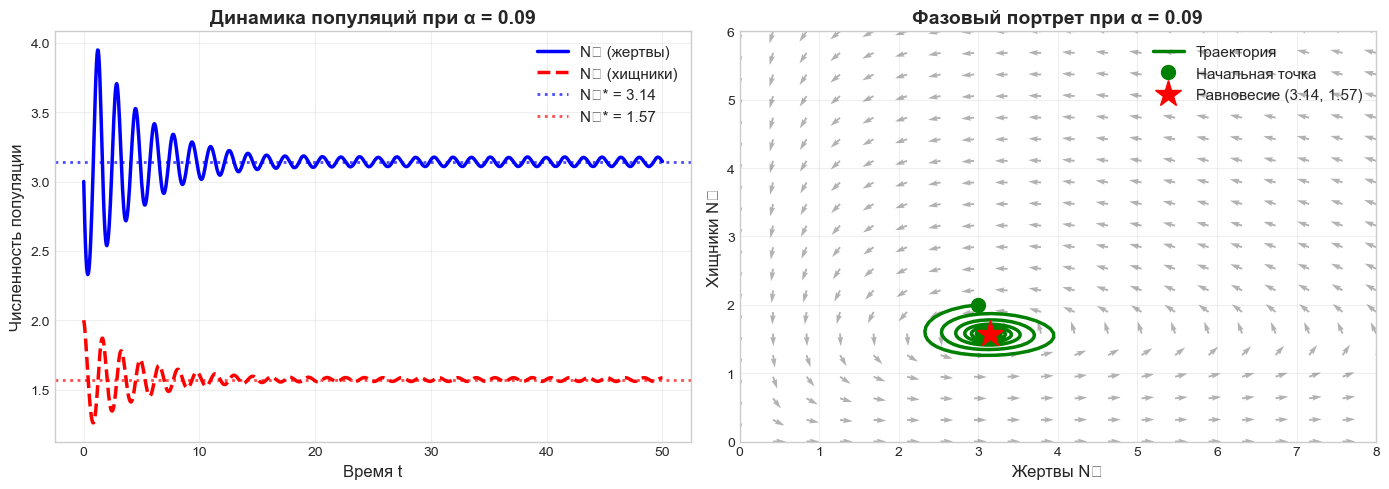

In [21]:
print("\nДЕТАЛЬНЫЙ АНАЛИЗ ПРИ α = 0.09")

alpha_val = 0.09
# ИСПРАВЛЕНИЕ: анализируем ТОЛЬКО внутреннюю точку
interior_eq = find_interior_equilibrium(epsilon_1, gamma_1, epsilon_2, gamma_2, alpha_val)

if interior_eq:
    print(f"\nВНУТРЕННЯЯ точка равновесия (сосуществование видов):")
    print(f"  N₁* = {interior_eq[0]:.4f}, N₂* = {interior_eq[1]:.4f}")
    
    J = jacobian_matrix(interior_eq[0], interior_eq[1], 
                       epsilon_1, gamma_1, epsilon_2, gamma_2, alpha_val)
    analysis = analyze_equilibrium(J)
    
    print(f"\n  Тип: {analysis['type']}")
    print(f"  Собственные значения: λ₁ = {analysis['eigenvalues'][0]:.4f}, "
          f"λ₂ = {analysis['eigenvalues'][1]:.4f}")
    print(f"  След: {analysis['trace']:.4f}, Определитель: {analysis['determinant']:.4f}")
    print(f"  Устойчивость: {'✓ АСИМПТОТИЧЕСКИ УСТОЙЧИВА' if analysis['trace'] < 0 else '✗ НЕУСТОЙЧИВА'}")
else:
    print("⚠ Внутренняя точка равновесия не найдена!")

# Построение детальных графиков (используем interior_eq)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
t = np.linspace(0, 50, 1000)
sol = solve_ivp(lotka_volterra_logistic, (0, 50), initial_condition,
               args=(epsilon_1, gamma_1, epsilon_2, gamma_2, alpha_val),
               t_eval=t, dense_output=True)

# Временные ряды
axes[0].plot(t, sol.y[0], 'b-', linewidth=2.5, label='N₁ (жертвы)')
axes[0].plot(t, sol.y[1], 'r--', linewidth=2.5, label='N₂ (хищники)')

# Отмечаем только внутреннюю точку равновесия
if interior_eq:
    axes[0].axhline(y=interior_eq[0], color='blue', linestyle=':', linewidth=2, alpha=0.7, 
                   label=f'N₁* = {interior_eq[0]:.2f}')
    axes[0].axhline(y=interior_eq[1], color='red', linestyle=':', linewidth=2, alpha=0.7, 
                   label=f'N₂* = {interior_eq[1]:.2f}')

axes[0].set_xlabel('Время t', fontsize=12)
axes[0].set_ylabel('Численность популяции', fontsize=12)
axes[0].set_title(f'Динамика популяций при α = {alpha_val}', fontsize=14, fontweight='bold')
axes[0].legend(loc='best', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Фазовый портрет
axes[1].plot(sol.y[0], sol.y[1], 'g-', linewidth=2.5, label='Траектория')
axes[1].plot(initial_condition[0], initial_condition[1], 'go', markersize=10, label='Начальная точка')

# Отмечаем только внутреннюю точку
if interior_eq:
    axes[1].plot(interior_eq[0], interior_eq[1], 'r*', markersize=20, 
                label=f'Равновесие ({interior_eq[0]:.2f}, {interior_eq[1]:.2f})')

# Векторное поле
N1_grid, N2_grid = np.meshgrid(np.linspace(0, 8, 20), np.linspace(0, 6, 20))
dN1dt = (epsilon_1 - gamma_1 * N2_grid) * N1_grid - alpha_val * N1_grid**2
dN2dt = (-epsilon_2 + gamma_2 * N1_grid) * N2_grid - alpha_val * N2_grid**2
magnitude = np.sqrt(dN1dt**2 + dN2dt**2)
dN1dt_norm = dN1dt / (magnitude + 1e-10)
dN2dt_norm = dN2dt / (magnitude + 1e-10)
axes[1].quiver(N1_grid, N2_grid, dN1dt_norm, dN2dt_norm, alpha=0.3, scale=50)

axes[1].set_xlabel('Жертвы N₁', fontsize=12)
axes[1].set_ylabel('Хищники N₂', fontsize=12)
axes[1].set_title(f'Фазовый портрет при α = {alpha_val}', fontsize=14, fontweight='bold')
axes[1].legend(loc='best', fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 8)
axes[1].set_ylim(0, 6)

plt.tight_layout()
plt.show()


In [27]:
print("ВЫВОДЫ О ХАРАКТЕРЕ СТАЦИОНАРНОЙ ТОЧКИ")

print("\nПРИ α < 0 (отрицательная логистическая поправка):")
print("   • Логистический член -α·N² становится положительным (+|α|·N²)")
print("   • Это соответствует ДОПОЛНИТЕЛЬНОМУ РОСТУ популяций")
print("   • Точка равновесия становится НЕУСТОЙЧИВОЙ (узел или фокус)")
print("   • Популяции стремятся к неограниченному росту")
print("   • На фазовом портрете: траектории уходят на бесконечность")

print("\nПРИ α > 0 (положительная логистическая поправка):")
print("   • Логистический член -α·N² отрицательный")
print("   • Это соответствует ОГРАНИЧЕНИЮ РОСТА (самоограничение)")
print("   • Точка равновесия становится УСТОЙЧИВОЙ (узел или фокус)")
print("   • Популяции стремятся к стационарным значениям")
print("   • На фазовом портрете: траектории спирально приближаются к равновесию")

print("\nПРИ α = 0 (классическая модель Лотки-Вольтерры):")
print("   • Точка равновесия - ЦЕНТР (нейтрально устойчива)")
print("   • Траектории - замкнутые орбиты (периодические колебания)")
print("   • Амплитуда зависит от начальных условий")

ВЫВОДЫ О ХАРАКТЕРЕ СТАЦИОНАРНОЙ ТОЧКИ

ПРИ α < 0 (отрицательная логистическая поправка):
   • Логистический член -α·N² становится положительным (+|α|·N²)
   • Это соответствует ДОПОЛНИТЕЛЬНОМУ РОСТУ популяций
   • Точка равновесия становится НЕУСТОЙЧИВОЙ (узел или фокус)
   • Популяции стремятся к неограниченному росту
   • На фазовом портрете: траектории уходят на бесконечность

ПРИ α > 0 (положительная логистическая поправка):
   • Логистический член -α·N² отрицательный
   • Это соответствует ОГРАНИЧЕНИЮ РОСТА (самоограничение)
   • Точка равновесия становится УСТОЙЧИВОЙ (узел или фокус)
   • Популяции стремятся к стационарным значениям
   • На фазовом портрете: траектории спирально приближаются к равновесию

ПРИ α = 0 (классическая модель Лотки-Вольтерры):
   • Точка равновесия - ЦЕНТР (нейтрально устойчива)
   • Траектории - замкнутые орбиты (периодические колебания)
   • Амплитуда зависит от начальных условий


In [28]:
print("ЧУВСТВИТЕЛЬНОСТЬ КЛАССИЧЕСКОЙ МОДЕЛИ")
print("\nЗАКЛЮЧЕНИЕ О ЧУВСТВИТЕЛЬНОСТИ:")
print("\nКлассическая модель Лотки-Вольтерры (α = 0) ОБЛАДАЕТ ВЫСОКОЙ")
print("ЧУВСТВИТЕЛЬНОСТЬЮ к малым изменениям структуры уравнений:")
print()
print("1. КАЧЕСТВЕННОЕ ИЗМЕНЕНИЕ ПОВЕДЕНИЯ:")
print("   • При α = 0: периодические колебания (центр)")
print("   • При α > 0: затухающие колебания → устойчивое равновесие")
print("   • При α < 0: расходящиеся колебания → неустойчивость")
print()
print("2. МАЛОЕ ВОЗМУЩЕНИЕ → БОЛЬШИЕ ПОСЛЕДСТВИЯ:")
print("   • Даже очень малое α ≠ 0 кардинально меняет поведение")
print("   • Замкнутые орбиты превращаются в спирали")
print("   • Нейтральная устойчивость сменяется асимптотической")
print()
print("3. СТРУКТУРНАЯ НЕУСТОЙЧИВОСТЬ:")
print("   • Точка типа ЦЕНТР не является 'грубой' (robust)")
print("   • Малые возмущения правых частей меняют качественное поведение")
print("   • Это критический случай в теории устойчивости")

ЧУВСТВИТЕЛЬНОСТЬ КЛАССИЧЕСКОЙ МОДЕЛИ

ЗАКЛЮЧЕНИЕ О ЧУВСТВИТЕЛЬНОСТИ:

Классическая модель Лотки-Вольтерры (α = 0) ОБЛАДАЕТ ВЫСОКОЙ
ЧУВСТВИТЕЛЬНОСТЬЮ к малым изменениям структуры уравнений:

1. КАЧЕСТВЕННОЕ ИЗМЕНЕНИЕ ПОВЕДЕНИЯ:
   • При α = 0: периодические колебания (центр)
   • При α > 0: затухающие колебания → устойчивое равновесие
   • При α < 0: расходящиеся колебания → неустойчивость

2. МАЛОЕ ВОЗМУЩЕНИЕ → БОЛЬШИЕ ПОСЛЕДСТВИЯ:
   • Даже очень малое α ≠ 0 кардинально меняет поведение
   • Замкнутые орбиты превращаются в спирали
   • Нейтральная устойчивость сменяется асимптотической

3. СТРУКТУРНАЯ НЕУСТОЙЧИВОСТЬ:
   • Точка типа ЦЕНТР не является 'грубой' (robust)
   • Малые возмущения правых частей меняют качественное поведение
   • Это критический случай в теории устойчивости


In [29]:
# ДОПОЛНИТЕЛЬНЫЕ ВОПРОСЫ

print("\n 1. СТРУКТУРНАЯ УСТОЙЧИВОСТЬ КЛАССИЧЕСКОЙ МОДЕЛИ:")
print("\n   НЕТ! Классическая модель Лотки-Вольтерры НЕ является структурно")
print("   устойчивой, несмотря на устойчивость к малым изменениям начальных")
print("   условий.")
print()
print("   Объяснение:")
print("   • Устойчивость по начальным условиям: при фиксированной структуре")
print("     уравнений малые изменения НУ дают малые изменения решения")
print("   • Структурная устойчивость: малые изменения ПРАВЫХ ЧАСТЕЙ уравнений")
print("     не должны менять качественное поведение")
print("   • В модели Лотки-Вольтерры: α = 0 → α ≠ 0 (даже очень малое)")
print("     кардинально меняет поведение (центр → фокус)")
print()
print("   ВЫВОД: Модель структурно НЕУСТОЙЧИВА!")

print("\n 2. ТОЧКА ТИПА ЦЕНТР И ЕЁ ИЗМЕНЕНИЯ:")
print("\n   • Точка типа ЦЕНТР НЕ является 'грубой' (robust) точкой покоя")
print("   • 'Грубость' означает сохранение качественного поведения при")
print("     малых возмущениях")
print()
print("   При добавлении логистической поправки:")
print("   • α > 0: ЦЕНТР → УСТОЙЧИВЫЙ ФОКУС/УЗЕЛ")
print("            (траектории спирально приближаются к равновесию)")
print("   • α < 0: ЦЕНТР → НЕУСТОЙЧИВЫЙ ФОКУС/УЗЕЛ")
print("            (траектории спирально удаляются от равновесия)")
print()
print("   Качественные изменения решения:")
print("   • Замкнутые орбиты → спирали")
print("   • Периодические колебания → затухающие/расходящиеся колебания")
print("   • Нейтральная устойчивость → асимптотическая/неустойчивость")

print("\n 3. ВЛИЯНИЕ ИЗЪЯТИЯ ПОПУЛЯЦИЙ (pN₁ и qN₂):")
print("\n   Система с изъятием:")
print("   dN₁/dt = (ε₁ - γ₁·N₂)·N₁ - p·N₁")
print("   dN₂/dt = (-ε₂ + γ₂·N₁)·N₂ - q·N₂")
print()
print("   Преобразуем:")
print("   dN₁/dt = ((ε₁ - p) - γ₁·N₂)·N₁")
print("   dN₂/dt = (-(ε₂ + q) + γ₂·N₁)·N₂")
print()
print("   Новые равновесные значения:")
print("   N₁* = (ε₂ + q)/γ₂  → УВЕЛИЧИВАЕТСЯ с ростом q")
print("   N₂* = (ε₁ - p)/γ₁  → УМЕНЬШАЕТСЯ с ростом p")
print()
print("   ПАРАДОКС ВОЛЬТЕРРА:")
print("   • Изъятие жертв (p > 0) → СРЕДНЯЯ ЧИСЛЕННОСТЬ ЖЕРТВ ВОЗРАСТАЕТ!")
print("   • Изъятие хищников (q > 0) → СРЕДНЯЯ ЧИСЛЕННОСТЬ ХИЩНИКОВ ПАДАЕТ")
print()
print("   Объяснение:")
print("   • Уменьшение хищников (q > 0) снижает давление на жертв")
print("   • Жертвы восстанавливаются быстрее")
print("   • Это контринтуитивный, но математически верный результат!")
print()
print("ПРИМЕНЕНИЕ: Объясняет, почему умеренный промысел хищников может увеличить их популяцию в долгосрочной перспективе")


 1. СТРУКТУРНАЯ УСТОЙЧИВОСТЬ КЛАССИЧЕСКОЙ МОДЕЛИ:

   НЕТ! Классическая модель Лотки-Вольтерры НЕ является структурно
   устойчивой, несмотря на устойчивость к малым изменениям начальных
   условий.

   Объяснение:
   • Устойчивость по начальным условиям: при фиксированной структуре
     уравнений малые изменения НУ дают малые изменения решения
   • Структурная устойчивость: малые изменения ПРАВЫХ ЧАСТЕЙ уравнений
     не должны менять качественное поведение
   • В модели Лотки-Вольтерры: α = 0 → α ≠ 0 (даже очень малое)
     кардинально меняет поведение (центр → фокус)

   ВЫВОД: Модель структурно НЕУСТОЙЧИВА!

 2. ТОЧКА ТИПА ЦЕНТР И ЕЁ ИЗМЕНЕНИЯ:

   • Точка типа ЦЕНТР НЕ является 'грубой' (robust) точкой покоя
   • 'Грубость' означает сохранение качественного поведения при
     малых возмущениях

   При добавлении логистической поправки:
   • α > 0: ЦЕНТР → УСТОЙЧИВЫЙ ФОКУС/УЗЕЛ
            (траектории спирально приближаются к равновесию)
   • α < 0: ЦЕНТР → НЕУСТОЙЧИВЫЙ ФОКУС/УЗЕЛ

In [ ]:
# print("ВИЗУАЛЬНОЕ СРАВНЕНИЕ ПОВЕДЕНИЯ ПРИ РАЗНЫХ α")

# fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# alpha_test = [0, 0.09, 0.2, 0.5]

# for idx, alpha_val in enumerate(alpha_test):
#     row = idx // 2      # Целочисленное деление: 0,0,1,1
#     col = idx % 2       # Остаток от деления: 0,1,0,1
    
#     # Решаем систему
#     sol = solve_ivp(lotka_volterra_logistic, (0, 40), initial_condition,
#                    args=(epsilon_1, gamma_1, epsilon_2, gamma_2, alpha_val),
#                    t_eval=np.linspace(0, 40, 1000), 
#                    dense_output=True,
#                    method='RK45',  # Явный метод Рунге-Кутты для стабильности
#                    rtol=1e-6, atol=1e-9)  # Точность
    
#     t_actual = sol.t
#     N1 = sol.y[0]
#     N2 = sol.y[1]
    
#     # Проверка на успешность решения
#     if not sol.success:
#         print(f"Предупреждение: решение для α={alpha_val} может быть неполным")
    
#     axes[row, col].plot(t_actual, N1, 'b-', linewidth=2, label='N₁')
#     axes[row, col].plot(t_actual, N2, 'r--', linewidth=2, label='N₂')
    
#     if alpha_val != 0:
#         equilibria = find_interior_equilibrium(epsilon_1, gamma_1, epsilon_2, gamma_2, alpha_val)
#         if len(equilibria) > 1:
#             eq = equilibria[-1]
#             axes[row, col].axhline(y=eq[0], color='blue', linestyle=':', alpha=0.7)
#             axes[row, col].axhline(y=eq[1], color='red', linestyle=':', alpha=0.7)
#     axes[row, col].set_xlabel('Время t', fontsize=11)
#     axes[row, col].set_ylabel('Численность', fontsize=11)
#     axes[row, col].set_title(f'α = {alpha_val:.2f}', fontsize=12, fontweight='bold')
#     axes[row, col].legend(loc='best', fontsize=9)
#     axes[row, col].grid(True, alpha=0.3)
#     axes[row, col].set_ylim(0, 6)
# plt.suptitle('Сравнение динамики при различных значениях α', fontsize=14, fontweight='bold', y=1.02)
# plt.tight_layout()
# plt.show()

# # Фазовые портреты для сравнения
# fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# for idx, alpha_val in enumerate(alpha_test):
#     sol = solve_ivp(lotka_volterra_logistic, (0, 40), initial_condition,
#                    args=(epsilon_1, gamma_1, epsilon_2, gamma_2, alpha_val),
#                    t_eval=np.linspace(0, 40, 1000),
#                    dense_output=True,
#                    method='RK45',
#                    rtol=1e-6, atol=1e-9)
#     N1 = sol.y[0]
#     N2 = sol.y[1]
    
#     axes[idx].plot(N1, N2, 'g-', linewidth=2.5)
#     axes[idx].plot(initial_condition[0], initial_condition[1], 'go', markersize=8)
    
#     if alpha_val != 0:
#         equilibria = find_interior_equilibrium(epsilon_1, gamma_1, epsilon_2, gamma_2, alpha_val)
#         if len(equilibria) > 1:
#             eq = equilibria[-1]
#             axes[idx].plot(eq[0], eq[1], 'r*', markersize=15)
#     axes[idx].set_xlabel('N₁', fontsize=11)
#     axes[idx].set_ylabel('N₂', fontsize=11)
#     axes[idx].set_title(f'α = {alpha_val:.2f}', fontsize=12, fontweight='bold')
#     axes[idx].grid(True, alpha=0.3)
#     axes[idx].set_xlim(0, 8)
#     axes[idx].set_ylim(0, 6)
# plt.suptitle('Фазовые портреты при различных α', fontsize=14, fontweight='bold', y=1.05)
# plt.tight_layout()
# plt.show()


ВИЗУАЛЬНОЕ СРАВНЕНИЕ ПОВЕДЕНИЯ ПРИ РАЗНЫХ α
✓ Найдена внутренняя точка: N₁* = 3.1415, N₂* = 1.5724
✓ Найдена внутренняя точка: N₁* = 3.2895, N₂* = 1.4474
✓ Найдена внутренняя точка: N₁* = 3.5385, N₂* = 1.0769


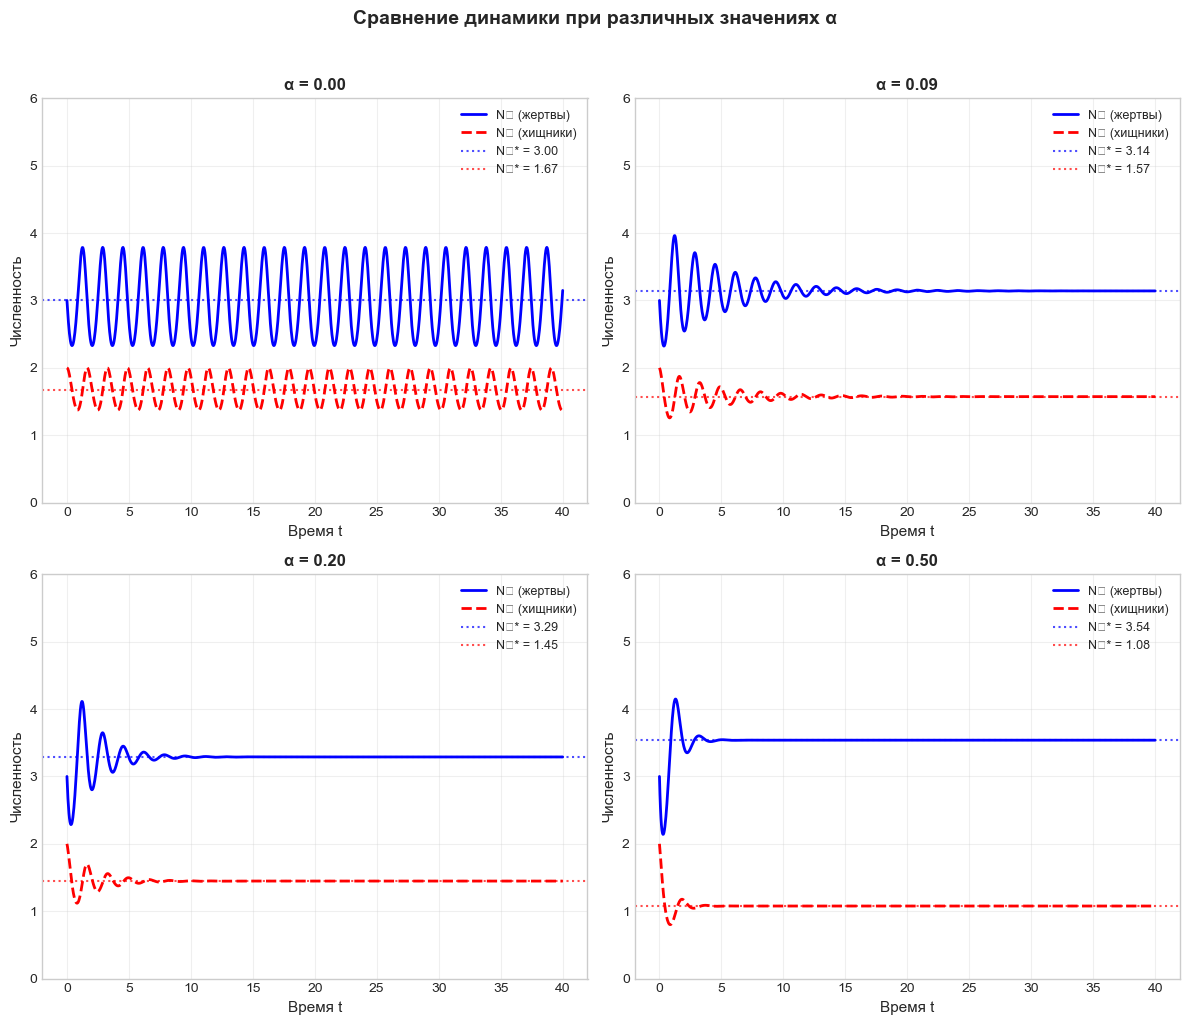


Фазовые портреты при различных α
--------------------------------------------------------------------------------
✓ Найдена внутренняя точка: N₁* = 3.1415, N₂* = 1.5724
✓ Найдена внутренняя точка: N₁* = 3.2895, N₂* = 1.4474
✓ Найдена внутренняя точка: N₁* = 3.5385, N₂* = 1.0769


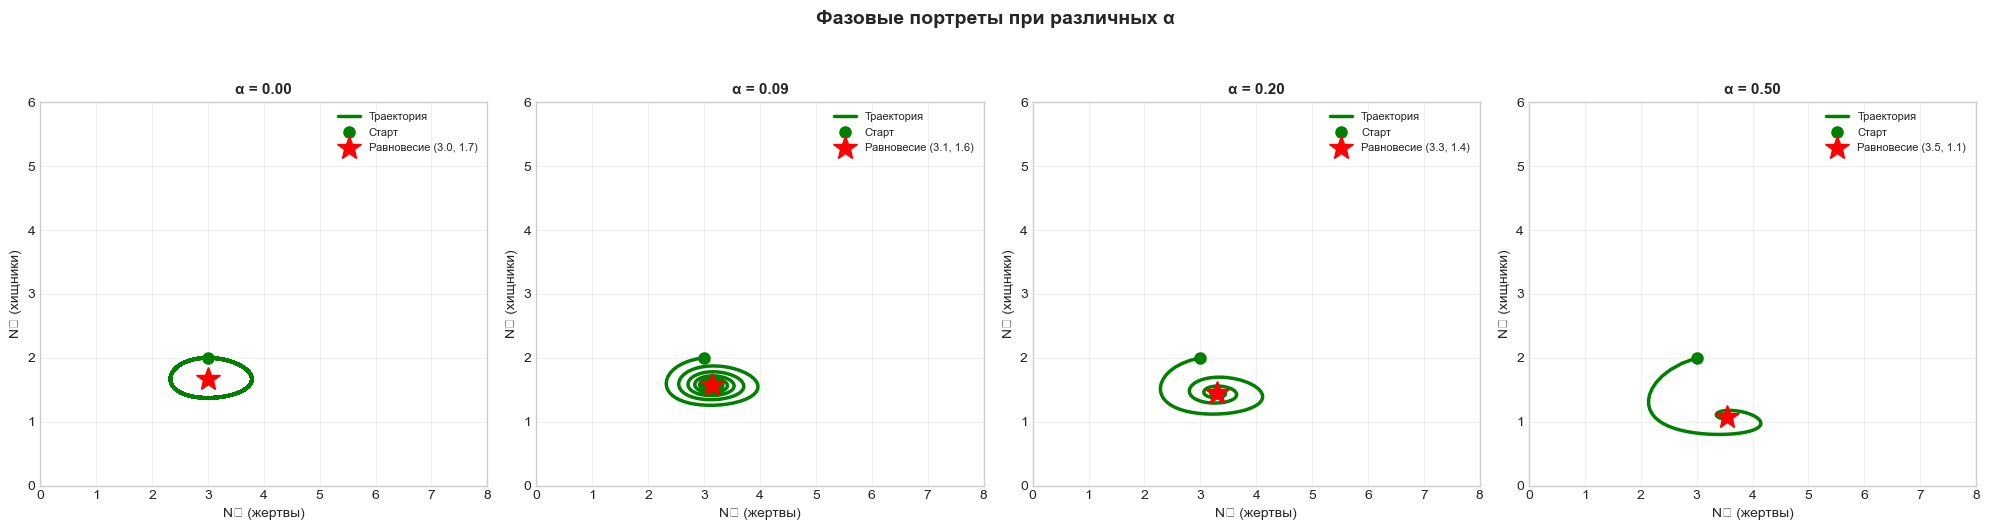


СВОДКА РЕЗУЛЬТАТОВ
  α    |   Точка равновесия   |      Тип точки       |  Устойчивость  
--------------------------------------------------------------------------------
 0.00  |     (3.00, 1.67)     |  ЦЕНТР (нейтрально)  |  ✗ Неустойчива 
✓ Найдена внутренняя точка: N₁* = 3.1415, N₂* = 1.5724
 0.09  |     (3.14, 1.57)     |   УСТОЙЧИВЫЙ ФОКУС   |   ✓ Устойчива  
✓ Найдена внутренняя точка: N₁* = 3.2895, N₂* = 1.4474
 0.20  |     (3.29, 1.45)     |   УСТОЙЧИВЫЙ ФОКУС   |   ✓ Устойчива  
✓ Найдена внутренняя точка: N₁* = 3.5385, N₂* = 1.0769
 0.50  |     (3.54, 1.08)     |   УСТОЙЧИВЫЙ ФОКУС   |   ✓ Устойчива  


In [26]:
print("ВИЗУАЛЬНОЕ СРАВНЕНИЕ ПОВЕДЕНИЯ ПРИ РАЗНЫХ α")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

alpha_test = [0, 0.09, 0.2, 0.5]

for idx, alpha_val in enumerate(alpha_test):
    row = idx // 2
    col = idx % 2
    
    # Решаем систему
    sol = solve_ivp(lotka_volterra_logistic, (0, 40), initial_condition,
                   args=(epsilon_1, gamma_1, epsilon_2, gamma_2, alpha_val),
                   t_eval=np.linspace(0, 40, 1000), 
                   dense_output=True,
                   method='RK45',
                   rtol=1e-6, atol=1e-9)
    
    t_actual = sol.t
    N1 = sol.y[0]
    N2 = sol.y[1]
    
    # Проверка на успешность решения
    if not sol.success:
        print(f"⚠ Предупреждение: решение для α={alpha_val} может быть неполным")
    
    # Временные ряды
    axes[row, col].plot(t_actual, N1, 'b-', linewidth=2, label='N₁ (жертвы)')
    axes[row, col].plot(t_actual, N2, 'r--', linewidth=2, label='N₂ (хищники)')
    
    # 🔧 ИСПРАВЛЕНИЕ: find_interior_equilibrium возвращает кортеж или None
    interior_eq = find_interior_equilibrium(epsilon_1, gamma_1, epsilon_2, gamma_2, alpha_val)
    
    if interior_eq is not None:
        # Отмечаем равновесные значения горизонтальными линиями
        axes[row, col].axhline(y=interior_eq[0], color='blue', linestyle=':', 
                              alpha=0.7, linewidth=1.5, label=f'N₁* = {interior_eq[0]:.2f}')
        axes[row, col].axhline(y=interior_eq[1], color='red', linestyle=':', 
                              alpha=0.7, linewidth=1.5, label=f'N₂* = {interior_eq[1]:.2f}')
    
    axes[row, col].set_xlabel('Время t', fontsize=11)
    axes[row, col].set_ylabel('Численность', fontsize=11)
    axes[row, col].set_title(f'α = {alpha_val:.2f}', fontsize=12, fontweight='bold')
    axes[row, col].legend(loc='best', fontsize=9)
    axes[row, col].grid(True, alpha=0.3)
    axes[row, col].set_ylim(0, 6)

plt.suptitle('Сравнение динамики при различных значениях α', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================================================
# Фазовые портреты для сравнения
# ============================================================================

print("\nФазовые портреты при различных α")
print("-"*80)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for idx, alpha_val in enumerate(alpha_test):
    sol = solve_ivp(lotka_volterra_logistic, (0, 40), initial_condition,
                   args=(epsilon_1, gamma_1, epsilon_2, gamma_2, alpha_val),
                   t_eval=np.linspace(0, 40, 1000),
                   dense_output=True,
                   method='RK45',
                   rtol=1e-6, atol=1e-9)
    
    N1 = sol.y[0]
    N2 = sol.y[1]
    
    # Траектория
    axes[idx].plot(N1, N2, 'g-', linewidth=2.5, label='Траектория')
    # Начальная точка
    axes[idx].plot(initial_condition[0], initial_condition[1], 'go', markersize=8, label='Старт')
    
    # 🔧 ИСПРАВЛЕНИЕ: проверяем на None, а не на длину списка
    interior_eq = find_interior_equilibrium(epsilon_1, gamma_1, epsilon_2, gamma_2, alpha_val)
    
    if interior_eq is not None:
        # Отмечаем точку равновесия
        axes[idx].plot(interior_eq[0], interior_eq[1], 'r*', markersize=18, 
                      label=f'Равновесие ({interior_eq[0]:.1f}, {interior_eq[1]:.1f})')
    
    axes[idx].set_xlabel('N₁ (жертвы)', fontsize=10)
    axes[idx].set_ylabel('N₂ (хищники)', fontsize=10)
    axes[idx].set_title(f'α = {alpha_val:.2f}', fontsize=11, fontweight='bold')
    axes[idx].legend(loc='best', fontsize=8)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim(0, 8)
    axes[idx].set_ylim(0, 6)

plt.suptitle('Фазовые портреты при различных α', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# ============================================================================
# Краткая сводка результатов
# ============================================================================

print("\n" + "="*80)
print("СВОДКА РЕЗУЛЬТАТОВ")
print("="*80)
print(f"{'α':^6} | {'Точка равновесия':^20} | {'Тип точки':^20} | {'Устойчивость':^15}")
print("-"*80)

for alpha_val in alpha_test:
    interior_eq = find_interior_equilibrium(epsilon_1, gamma_1, epsilon_2, gamma_2, alpha_val)
    
    if interior_eq is not None:
        J = jacobian_matrix(interior_eq[0], interior_eq[1], 
                           epsilon_1, gamma_1, epsilon_2, gamma_2, alpha_val)
        analysis = analyze_equilibrium(J)
        
        point_str = f"({interior_eq[0]:.2f}, {interior_eq[1]:.2f})"
        stability = "✓ Устойчива" if analysis['trace'] < 0 else "✗ Неустойчива"
        
        print(f"{alpha_val:^6.2f} | {point_str:^20} | {analysis['type']:^20} | {stability:^15}")
    else:
        print(f"{alpha_val:^6.2f} | {'Нет точки':^20} | {'-':^20} | {'-':^15}")